In [ ]:
!pip install ucimlrepo

#**Importação**

In [ ]:
import pickle as pkl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import NeighborhoodComponentsAnalysis
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from matplotlib.colors import ListedColormap


#TREINO

In [ ]:

print("="*60)
print("LABORATÓRIO 4 - DÍGITOS MANUSCRITOS (0-9)")
print("="*60)

# ==========================================================
# ATIVIDADE 1 - Carregar dataset de dígitos manuscritos (id=80)
# ==========================================================

# Carregar dataset de dígitos manuscritos
digits = fetch_ucirepo(id=80)

# Dados
X = digits.data.features
y = digits.data.targets.values.ravel()

print(f"\n📊 Dataset de Dígitos Manuscritos:")
print(f"Total de amostras: {len(X)}")
print(f"Número de features: {X.shape[1]}")
print(f"Classes (dígitos): {np.unique(y)}")

# Converter para números (LabelEncoder)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print(f"Classes codificadas: {np.unique(y_encoded)}")

# ==========================================================
# ATIVIDADE 1 - Normalização + NCA (redução para 2D)
# ==========================================================

print("\n🔧 Aplicando StandardScaler + NCA (redução para 2D)...")

nca_pipeline = make_pipeline(
    StandardScaler(),
    NeighborhoodComponentsAnalysis(n_components=2, random_state=42)
)

# Aplicar redução de dimensão
X_nca = nca_pipeline.fit_transform(X, y_encoded)

print(f"Dimensão original: {X.shape}")
print(f"Dimensão após NCA: {X_nca.shape}")

# ==========================================================
# ATIVIDADE 2 - Divisão treino/teste (1/3 para teste)
# ==========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_nca, y_encoded,
    test_size=0.33,
    stratify=y_encoded,
    random_state=42
)

# Guardar também os labels originais (strings) para visualização
y_test_strings = label_encoder.inverse_transform(y_test)

print(f"\n📊 Divisão dos dados:")
print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste: {X_test.shape[0]} amostras")


LABORATÓRIO 4 - DÍGITOS MANUSCRITOS (0-9)

📊 Dataset de Dígitos Manuscritos:
Total de amostras: 5620
Número de features: 64
Classes (dígitos): [0 1 2 3 4 5 6 7 8 9]
Classes codificadas: [0 1 2 3 4 5 6 7 8 9]

🔧 Aplicando StandardScaler + NCA (redução para 2D)...
Dimensão original: (5620, 64)
Dimensão após NCA: (5620, 2)

📊 Divisão dos dados:
Treino: 3765 amostras
Teste: 1855 amostras


#TESTE

In [ ]:

# ==========================================================
# ATIVIDADE 2 - Treino do modelo LogisticRegression
# ==========================================================

print("\n🔧 Treinando modelo LogisticRegression...")

model = LogisticRegression(
    random_state=42,
    solver='lbfgs',
    max_iter=200,
    multi_class='auto'
)

model.fit(X_train, y_train)
print("✅ Modelo treinado com sucesso!")

# ==========================================================
# ATIVIDADE 2 - Salvar modelo e dados de teste
# ==========================================================

print("\n💾 Salvando modelo e dados...")

# Salvar modelo
with open("digits_lr_nca.pkl", "wb") as f:
    pkl.dump(model, f)

# Salvar pipeline NCA
with open("digits_nca_pipeline.pkl", "wb") as f:
    pkl.dump(nca_pipeline, f)

# Salvar dados de teste
with open("digits_test_nca.pkl", "wb") as f:
    pkl.dump((X_test, y_test), f)

# Salvar o label encoder
with open("digits_label_encoder.pkl", "wb") as f:
    pkl.dump(label_encoder, f)

print("✅ Modelo, pipeline e dados salvos com sucesso!")

# ==========================================================
# ATIVIDADE 3 - Teste do modelo (carregar e avaliar)
# ==========================================================

print("\n" + "="*60)
print("ATIVIDADE 3 - TESTE DO MODELO")
print("="*60)

# Carregar os dados salvos
with open("digits_lr_nca.pkl", "rb") as f:
    model = pkl.load(f)

with open("digits_nca_pipeline.pkl", "rb") as f:
    nca_pipeline = pkl.load(f)

with open("digits_test_nca.pkl", "rb") as f:
    X_test, y_test = pkl.load(f)

with open("digits_label_encoder.pkl", "rb") as f:
    label_encoder = pkl.load(f)

# Fazer predições
y_pred = model.predict(X_test)

# Calcular acurácia
accuracy = accuracy_score(y_test, y_pred)
print(f"\n✅ Acurácia do modelo no teste: {100*accuracy:.2f}%")

# Relatório de classificação
print("\n📊 Relatório de Classificação por Dígito:")
print(classification_report(y_test, y_pred,
                          target_names=[str(i) for i in range(10)]))

# Matriz de confusão
print("\n📈 Matriz de Confusão:")
cm = confusion_matrix(y_test, y_pred)
print(cm)



🔧 Treinando modelo LogisticRegression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


✅ Modelo treinado com sucesso!

💾 Salvando modelo e dados...
✅ Modelo, pipeline e dados salvos com sucesso!

ATIVIDADE 3 - TESTE DO MODELO

✅ Acurácia do modelo no teste: 76.44%

📊 Relatório de Classificação por Dígito:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       183
           1       0.64      0.70      0.67       188
           2       0.87      0.82      0.84       184
           3       0.79      0.89      0.84       189
           4       0.84      0.87      0.86       187
           5       0.53      0.52      0.53       184
           6       0.88      0.84      0.86       184
           7       0.88      0.80      0.84       187
           8       0.72      0.66      0.69       183
           9       0.57      0.59      0.58       186

    accuracy                           0.76      1855
   macro avg       0.77      0.76      0.76      1855
weighted avg       0.77      0.76      0.76      1855


📈 Matriz de Confusão

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


#**Predição e Região de Decisão**


🎨 Gerando visualizações...


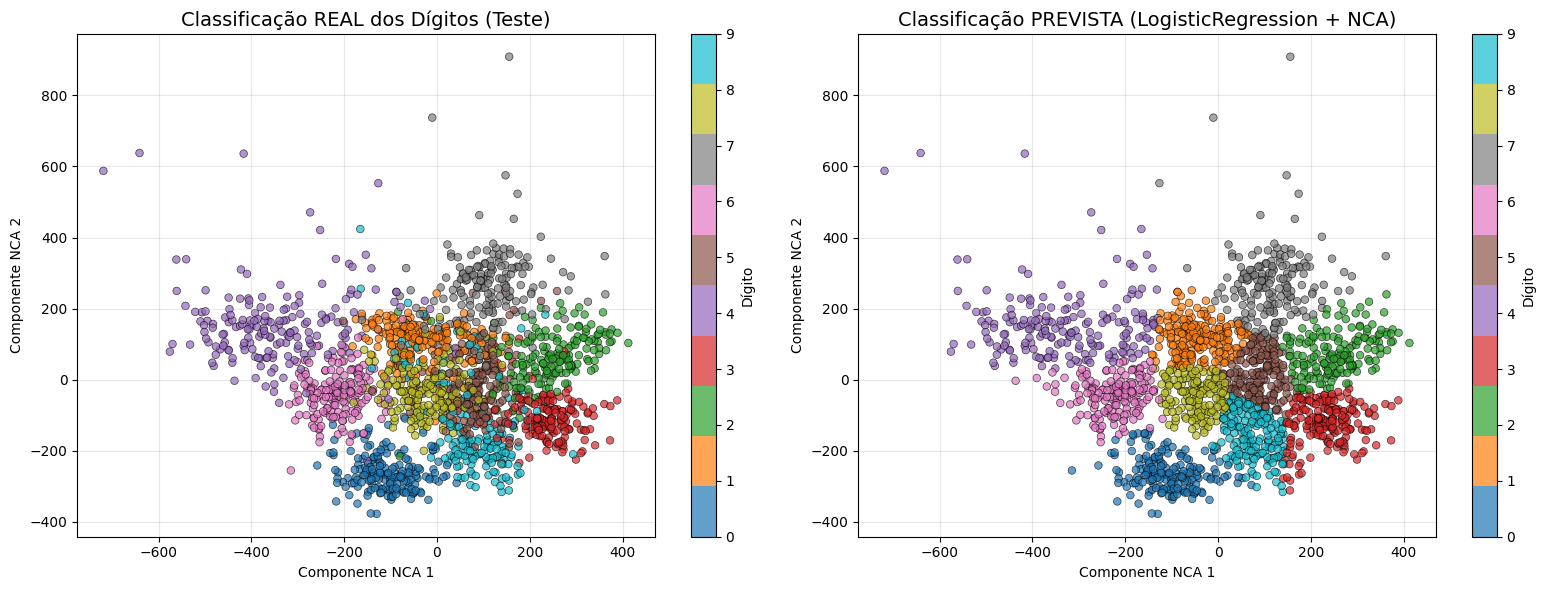


🎨 Gerando mapa de regiões de decisão...
Calculando regiões de decisão...


In [ ]:

# ==========================================================
# ATIVIDADE 3 - Visualização da nuvem de pontos (real vs previsto)
# ==========================================================

print("\n🎨 Gerando visualizações...")

# Cores para os 10 dígitos
cmap_bold = plt.cm.tab10

# Criar figura com 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Classificação REAL
scatter1 = ax1.scatter(X_test[:, 0], X_test[:, 1],
                       c=y_test, cmap=cmap_bold,
                       s=30, alpha=0.7, edgecolors='black', linewidth=0.5)
ax1.set_title("Classificação REAL dos Dígitos (Teste)", fontsize=14)
ax1.set_xlabel("Componente NCA 1")
ax1.set_ylabel("Componente NCA 2")
ax1.grid(True, alpha=0.3)

# Plot 2: Classificação PREVISTA
scatter2 = ax2.scatter(X_test[:, 0], X_test[:, 1],
                       c=y_pred, cmap=cmap_bold,
                       s=30, alpha=0.7, edgecolors='black', linewidth=0.5)
ax2.set_title("Classificação PREVISTA (LogisticRegression + NCA)", fontsize=14)
ax2.set_xlabel("Componente NCA 1")
ax2.set_ylabel("Componente NCA 2")
ax2.grid(True, alpha=0.3)

# Adicionar colorbars
cbar1 = plt.colorbar(scatter1, ax=ax1, ticks=range(10))
cbar1.set_label('Dígito')
cbar2 = plt.colorbar(scatter2, ax=ax2, ticks=range(10))
cbar2.set_label('Dígito')

plt.tight_layout()
plt.show()

# ==========================================================
# ATIVIDADE 3 - Visualização com regiões de decisão
# ==========================================================

print("\n🎨 Gerando mapa de regiões de decisão...")

# Criar malha para mostrar as regiões de decisão
x_min, x_max = X_nca[:, 0].min() - 0.5, X_nca[:, 0].max() + 0.5
y_min, y_max = X_nca[:, 1].min() - 0.5, X_nca[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05),
                     np.arange(y_min, y_max, 0.05))

# Predizer para toda a malha
print("Calculando regiões de decisão...")
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plotar
plt.figure(figsize=(12, 10))
plt.contourf(xx, yy, Z, cmap='tab10', alpha=0.3)

# Plotar pontos de teste
scatter = plt.scatter(X_test[:, 0], X_test[:, 1],
                     c=y_test, cmap='tab10',
                     s=30, edgecolors='black', linewidth=0.5)

plt.title("Regiões de Decisão - Dígitos Manuscritos\n(LogisticRegression + NCA)", fontsize=14)
plt.xlabel("Componente NCA 1")
plt.ylabel("Componente NCA 2")

cbar = plt.colorbar(scatter, ticks=range(10))
cbar.set_label('Dígito')
plt.grid(True, alpha=0.3)
plt.show()

# ==========================================================
# FUNÇÃO DE PREDIÇÃO (opcional)
# ==========================================================

def predict_digit(features):
    """
    Prediz o dígito com base nas features (64 pixels)
    """
    features_nca = nca_pipeline.transform(features.reshape(1, -1))
    predicao_num = model.predict(features_nca)[0]
    return predicao_num

print("\n🔮 Exemplo: Primeira amostra do teste")
print(f"Dígito real: {y_test[0]}")
print(f"Dígito previsto: {y_pred[0]}")

print("\n" + "="*60)
print("✅ LABORATÓRIO 4 CONCLUÍDO COM SUCESSO!")
print("="*60)